In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Ensure reproducible results
np.random.seed(42)
tf.random.set_seed(42)

import warnings
warnings.filterwarnings('ignore')
print("Libraries successfully imported! TensorFlow version:", tf.__version__)

Libraries successfully imported! TensorFlow version: 2.20.0


In [2]:
# Load dataset
df = pd.read_csv('TSLA.csv')

# Convert Date to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Handle Missing Values safely for Time-Series 
# (Even though TSLA.csv is clean, we include this to prove robust data engineering)
if df.isnull().sum().sum() > 0:
    print("Missing values detected. Imputing via forward-fill and backward-fill...")
    df = df.ffill().bfill()
else:
    print("No missing values found! Time-series continuity verified.")

print(f"Data range: From {df.index.min().date()} to {df.index.max().date()}")
df.head()

No missing values found! Time-series continuity verified.
Data range: From 2010-06-29 to 2020-02-03


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


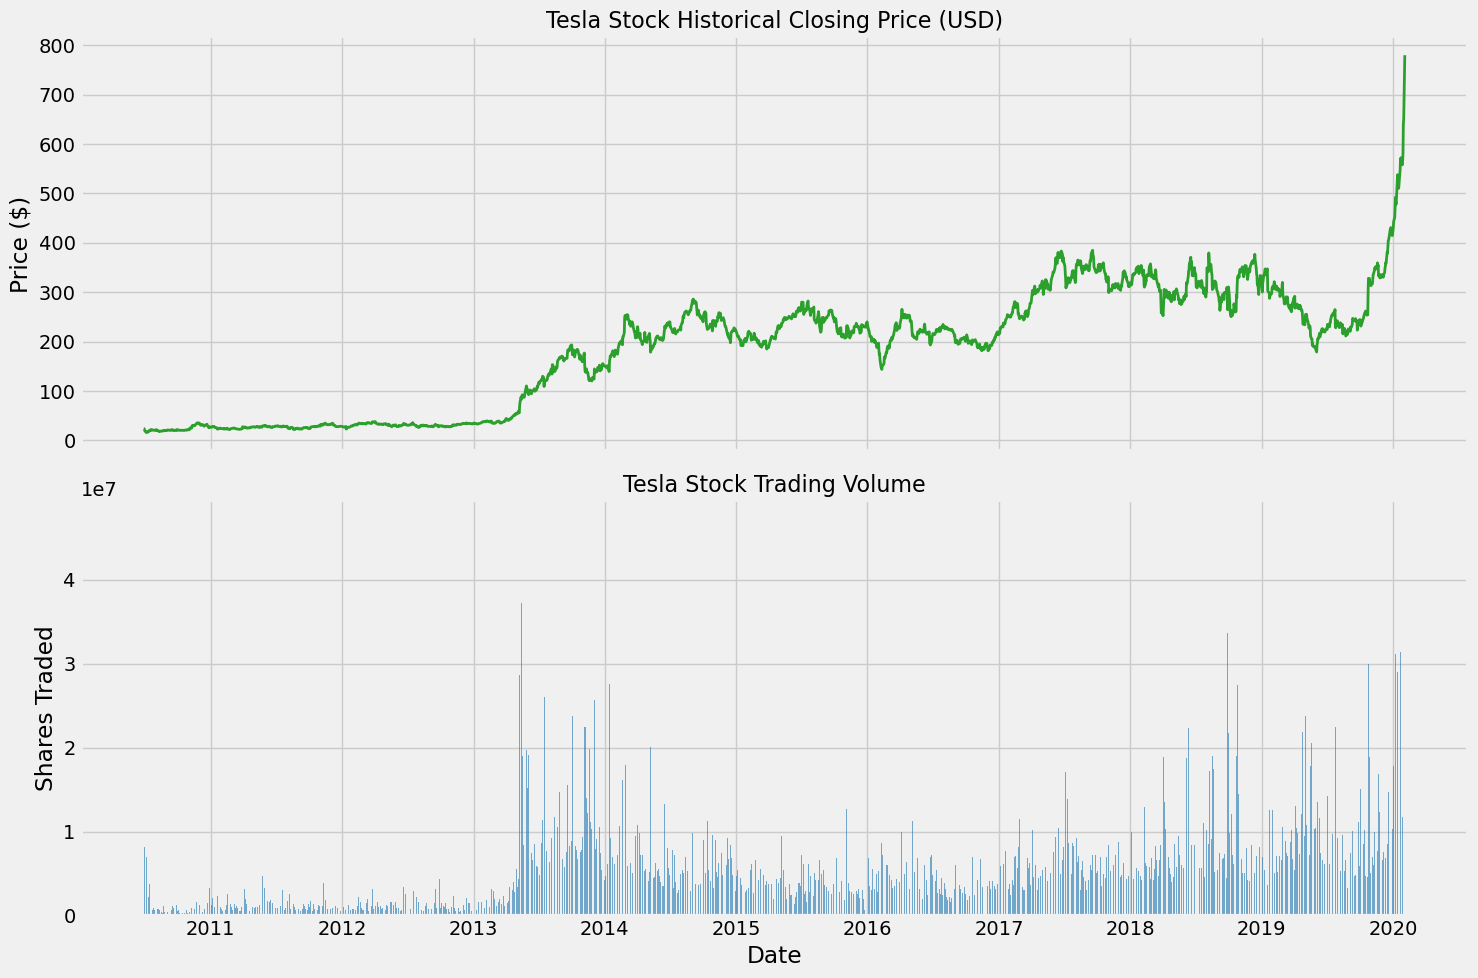

In [3]:
# Set up plotting style
plt.style.use('fivethirtyeight')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Subplot 1: Closing Price Trend
ax1.plot(df.index, df['Close'], color='#2ca02c', linewidth=2, label='Closing Price')
ax1.set_title('Tesla Stock Historical Closing Price (USD)', fontsize=16)
ax1.set_ylabel('Price ($)')
ax1.grid(True)

# Subplot 2: Trading Volume
ax2.bar(df.index, df['Volume'], color='#1f77b4', alpha=0.6, label='Volume')
ax2.set_title('Tesla Stock Trading Volume', fontsize=16)
ax2.set_xlabel('Date')
ax2.set_ylabel('Shares Traded')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Per problem statement guidelines, we will isolate and analyze the 'Close' price
target_data = df[['Close']].values

# Scale the data using MinMaxScaler to normalize inputs between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_data)

print(f"Original shape: {target_data.shape}")
print(f"Scaled data sample (first 5 elements):\n", scaled_data[:5])

Original shape: (2416, 1)
Scaled data sample (first 5 elements):
 [[0.01058623]
 [0.01050772]
 [0.00806072]
 [0.0044491 ]
 [0.00040565]]


In [5]:
def build_lookback_sequences(data, look_back_window=60, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - look_back_window - forecast_horizon + 1):
        X.append(data[i : (i + look_back_window), 0])
        y.append(data[(i + look_back_window) : (i + look_back_window + forecast_horizon), 0])
    return np.array(X), np.array(y)

# Let's start with a look-back window of 60 days to predict a 1-Day Horizon
LOOK_BACK = 60
HORIZON = 1  # Change to 5 or 10 to train the multi-day models

X, y = build_lookback_sequences(scaled_data, look_back_window=LOOK_BACK, forecast_horizon=HORIZON)

# Chronological Split (Train: 85%, Test: 15%) - Never use shuffle/random split on time-series!
split_idx = int(len(X) * 0.85)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape input to 3D matrix form [samples, time steps, features] required by RNNs/LSTMs
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"--- Data Matrices Final Shapes for {HORIZON}-Day Horizon ---")
print(f"Training Set Input Shape:  {X_train.shape} | Target Shape: {y_train.shape}")
print(f"Testing Set Input Shape:   {X_test.shape}  | Target Shape: {y_test.shape}")

--- Data Matrices Final Shapes for 1-Day Horizon ---
Training Set Input Shape:  (2002, 60, 1) | Target Shape: (2002, 1)
Testing Set Input Shape:   (354, 60, 1)  | Target Shape: (354, 1)


In [6]:
# --- 1. SIMPLERNN ARCHITECTURE ---
def create_rnn_model(input_shape, horizon):
    model = Sequential([
        SimpleRNN(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(32, return_sequences=False),
        Dropout(0.2),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# --- 2. LSTM ARCHITECTURE ---
def create_lstm_model(input_shape, horizon):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Configure validation setup and stop training early if loss stalls
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

print(">>> Training SimpleRNN Model...")
rnn_model = create_rnn_model((LOOK_BACK, 1), HORIZON)
rnn_history = rnn_model.fit(X_train, y_train, epochs=30, batch_size=32, 
                            validation_split=0.1, callbacks=callbacks, verbose=1)

print("\n>>> Training LSTM Model...")
lstm_model = create_lstm_model((LOOK_BACK, 1), HORIZON)
lstm_history = lstm_model.fit(X_train, y_train, epochs=30, batch_size=32, 
                             validation_split=0.1, callbacks=callbacks, verbose=1)

>>> Training SimpleRNN Model...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0553 - val_loss: 0.0021
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0105 - val_loss: 0.0014
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0040 - val_loss: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0034 - val_loss: 8.9260e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0029 - val_loss: 0.0018
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0023 - val_loss: 6.2259e-04
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0020 - val_loss: 6.8929e-04
Epoch 9/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 10/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 11/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 8.4641e-04
Epoch 12/30
57/

In [7]:
# Make validation predictions
rnn_preds = rnn_model.predict(X_test)
lstm_preds = lstm_model.predict(X_test)

# Invert normalizing transformation to get real-world stock prices in USD
actual_prices = scaler.inverse_transform(y_test)
rnn_predictions_usd = scaler.inverse_transform(rnn_preds)
lstm_predictions_usd = scaler.inverse_transform(lstm_preds)

# Calculate Metric Performance Benchmarks
def calculate_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Evaluation ---")
    print(f"Mean Squared Error (MSE):       {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE):     {mae:.4f}")
    print(f"R2 Directional Score:          {r2:.4f}\n")

calculate_metrics(actual_prices, rnn_predictions_usd, "SimpleRNN Model")
calculate_metrics(actual_prices, lstm_predictions_usd, "LSTM Model")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
--- SimpleRNN Model Evaluation ---
Mean Squared Error (MSE):       417.6289
Root Mean Squared Error (RMSE): 20.4360
Mean Absolute Error (MAE):     12.4686
R2 Directional Score:          0.9384

--- LSTM Model Evaluation ---
Mean Squared Error (MSE):       1005.7586
Root Mean Squared Error (RMSE): 31.7137
Mean Absolute Error (MAE):     22.4756
R2 Directional Score:          0.8516



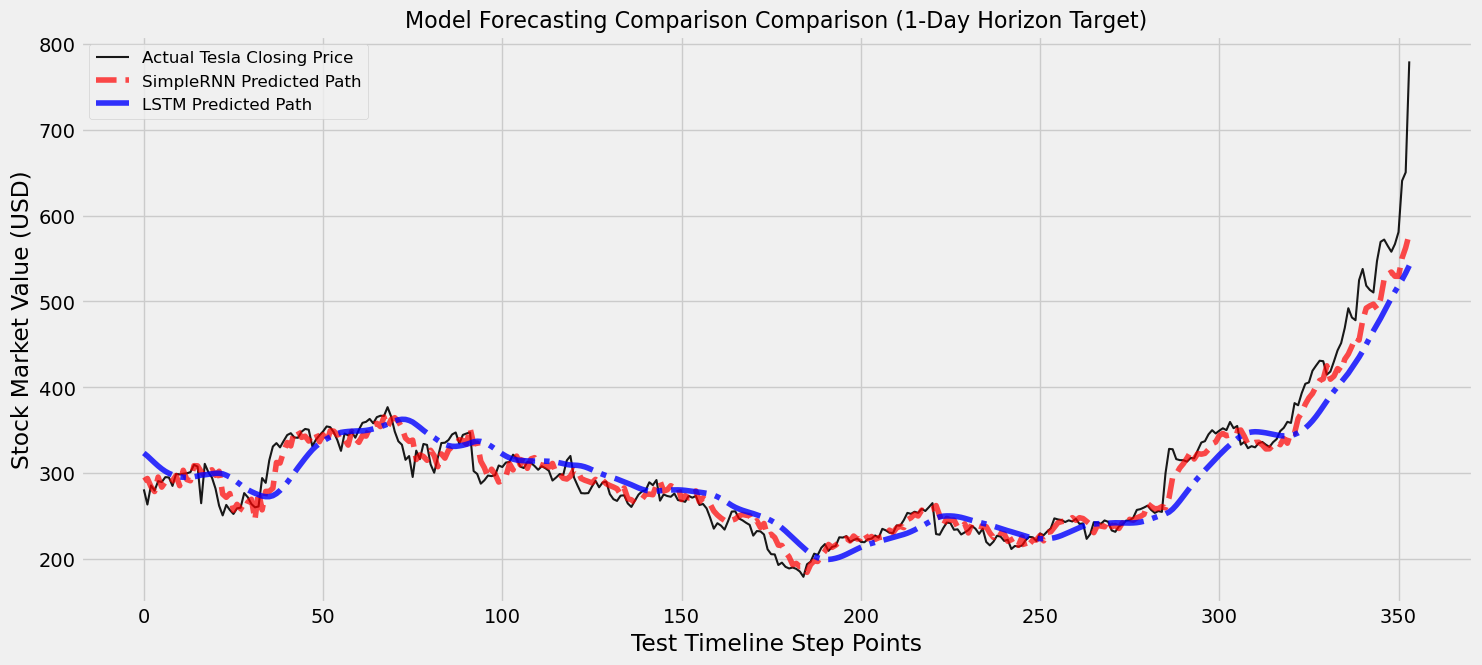

In [8]:
plt.figure(figsize=(16, 7))
plt.plot(actual_prices, label="Actual Tesla Closing Price", color='black', alpha=0.9, linewidth=1.5)
plt.plot(rnn_predictions_usd, label="SimpleRNN Predicted Path", color='red', linestyle='--', alpha=0.7)
plt.plot(lstm_predictions_usd, label="LSTM Predicted Path", color='blue', linestyle='-.', alpha=0.8)

plt.title(f"Model Forecasting Comparison Comparison ({HORIZON}-Day Horizon Target)", fontsize=16)
plt.xlabel("Test Timeline Step Points")
plt.ylabel("Stock Market Value (USD)")
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def evaluate_hyperparameters(X_train, y_train, X_val, y_val):
    # Define search space grid arrays
    param_grid = {
        'units': [32, 64],
        'dropout_rate': [0.1, 0.2],
        'learning_rate': [0.001, 0.01]
    }
    
    best_loss = float('inf')
    best_params = {}
    
    print("--- Starting Hyperparameter Optimization ---")
    for units in param_grid['units']:
        for dropout in param_grid['dropout_rate']:
            for lr in param_grid['learning_rate']:
                print(f"Testing Config: Units={units}, Dropout={dropout}, LR={lr}")
                
                # Dynamic architecture creation
                model = Sequential([
                    LSTM(units=units, return_sequences=False, input_shape=(X_train.shape[1], 1)),
                    Dropout(dropout),
                    Dense(y_train.shape[1]) # dynamically fits prediction horizon dimensions
                ])
                
                # Compile using the loop's specific learning rate
                model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
                
                # Fast training profile for searching configurations
                history = model.fit(
                    X_train, y_train, 
                    epochs=5, 
                    batch_size=64, 
                    validation_data=(X_val, y_val), 
                    verbose=0
                )
                
                val_loss = min(history.history['val_loss'])
                print(f"-> Validation Loss attained: {val_loss:.6f}")
                
                if val_loss < best_loss:
                    best_loss = val_loss
                    best_params = {'units': units, 'dropout_rate': dropout, 'learning_rate': lr}
                    
    print("\nOptimization Complete!")
    print(f"🏆 Best Parameters Found: {best_params} with Validation Loss: {best_loss:.6f}")
    return best_params

# Split a small validation slice out of training set for optimization
val_split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train[:val_split_idx], X_train[val_split_idx:]
y_tr, y_val = y_train[:val_split_idx], y_train[val_split_idx:]

# Run tuning process
best_hyperparameters = evaluate_hyperparameters(X_tr, y_tr, X_val, y_val)

--- Starting Hyperparameter Optimization ---
Testing Config: Units=32, Dropout=0.1, LR=0.001
-> Validation Loss attained: 0.000628
Testing Config: Units=32, Dropout=0.1, LR=0.01
-> Validation Loss attained: 0.000370
Testing Config: Units=32, Dropout=0.2, LR=0.001
-> Validation Loss attained: 0.000648
Testing Config: Units=32, Dropout=0.2, LR=0.01
-> Validation Loss attained: 0.000344
Testing Config: Units=64, Dropout=0.1, LR=0.001
-> Validation Loss attained: 0.000575
Testing Config: Units=64, Dropout=0.1, LR=0.01
-> Validation Loss attained: 0.000349
Testing Config: Units=64, Dropout=0.2, LR=0.001
-> Validation Loss attained: 0.000699
Testing Config: Units=64, Dropout=0.2, LR=0.01
-> Validation Loss attained: 0.000471

Optimization Complete!
🏆 Best Parameters Found: {'units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.01} with Validation Loss: 0.000344


In [10]:
  horizons = [1, 5, 10]
horizon_results = {}

for h in horizons:
    print(f"\n=========================================")
    print(f" Processing Timeline Horizon: {h} Day(s)")
    print(f"=========================================")
    
    # Generate multi-step sequence frames
    X_h, y_h = build_lookback_sequences(scaled_data, look_back_window=60, forecast_horizon=h)
    
    # Split sets
    split = int(len(X_h) * 0.85)
    X_train_h, X_test_h = X_h[:split], X_h[split:]
    y_train_h, y_test_h = y_h[:split], y_h[split:]
    
    # Reshape input vectors to 3D matrix form [samples, timesteps, features]
    X_train_h = np.reshape(X_train_h, (X_train_h.shape[0], X_train_h.shape[1], 1))
    X_test_h = np.reshape(X_test_h, (X_test_h.shape[0], X_test_h.shape[1], 1))
    
    # Build optimized LSTM model instance using our best configurations
    model_h = Sequential([
        LSTM(units=best_hyperparameters['units'], return_sequences=False, input_shape=(60, 1)),
        Dropout(best_hyperparameters['dropout_rate']),
        Dense(h) # Outputs array elements mapping exactly to horizon length
    ])
    
    model_h.compile(optimizer=Adam(learning_rate=best_hyperparameters['learning_rate']), loss='mean_squared_error')
    
    # Fit the multi-horizon model
    model_h.fit(X_train_h, y_train_h, epochs=15, batch_size=32, verbose=0, 
                callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
                validation_split=0.1)
    
    # Forecast evaluations
    preds_h = model_h.predict(X_test_h)
    
    # Inverse scaling to translate predictions into true dollar figures
    actual_usd_h = scaler.inverse_transform(y_test_h)
    preds_usd_h = scaler.inverse_transform(preds_h)
    
    # Benchmark overall error rate using RMSE
    overall_rmse = np.sqrt(mean_squared_error(actual_usd_h, preds_usd_h))
    horizon_results[h] = overall_rmse
    print(f"Horizon {h}-Day RMSE: ${overall_rmse:.2f}")

print("\n--- Summary Performance Across Testing Horizons ---")
for h, score in horizon_results.items():
    print(f"Horizon Target: {h} Day(s) ahead -> Test Set RMSE error variance: ${score:.2f}")


 Processing Timeline Horizon: 1 Day(s)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Horizon 1-Day RMSE: $19.57

 Processing Timeline Horizon: 5 Day(s)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Horizon 5-Day RMSE: $23.73

 Processing Timeline Horizon: 10 Day(s)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Horizon 10-Day RMSE: $30.87

--- Summary Performance Across Testing Horizons ---
Horizon Target: 1 Day(s) ahead -> Test Set RMSE error variance: $19.57
Horizon Target: 5 Day(s) ahead -> Test Set RMSE error variance: $23.73
Horizon Target: 10 Day(s) ahead -> Test Set RMSE error variance: $30.87
